<a href="https://colab.research.google.com/github/pyafv/assets/blob/main/jupyter/multiprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install **pyafv** in Google Colab

In [ ]:
!pip install pyafv

In [2]:
import numpy as np
import pyafv as afv
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [3]:
points = np.random.default_rng(42).random((10_000, 2)) * 120.0
phys = afv.PhysicalParams(r=1.0)

# Using Python multiprocessing-based domain decomposition
sim = afv.ParallelFiniteVoronoiSimulator(
    points,
    phys,
    grid_shape=(2, 2),    # domain grid
    n_workers=4,          # number of workers
)

In [4]:
diag = sim.build()
print(f"Unique PIDs for workers: {np.unique(diag["pids"])}")

Unique PIDs for workers: [35735 35736 35737 35738]


In [5]:
dt = 0.01

# Important:
# - Place the time-stepping loop inside the context manager to avoid repeatedly creating and shutting down process pools.
# - When running this in a Python script on Windows/macOS, put it behind the standard `if __name__ == "__main__":` guard.
with sim:
    for _ in tqdm(range(10)):
        diag = sim.build()
        points += diag["forces"] * dt
        sim.update_positions(points)

  0%|          | 0/10 [00:00<?, ?it/s]

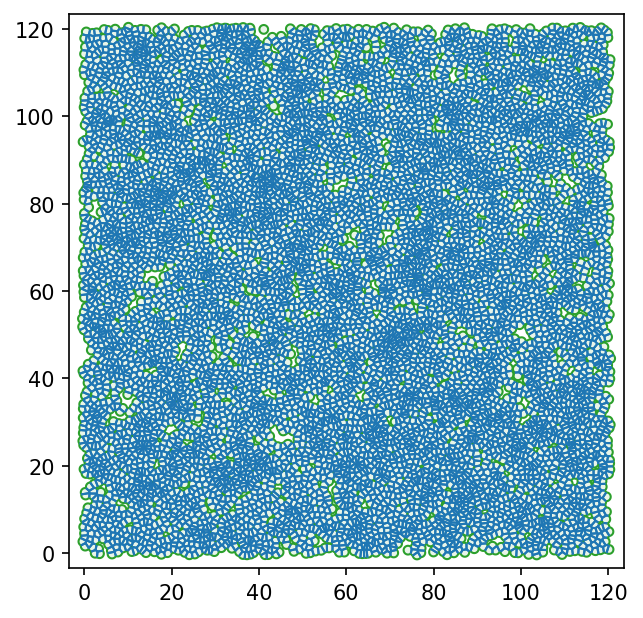

In [6]:
# visualize
diag = sim.build(plot_mode=True)  # must set `plot_mode=True`

fig, ax = plt.subplots(dpi=150)
afv.visualize_2d_parallel(points, diag, r=1, ax=ax)  # only accept `diag` with `plot_mode=True`
plt.show()

### Comparing forces computed by the serial and parallel simulators

In [7]:
sim_serial = afv.FiniteVoronoiSimulator(points, phys)
diag_serial = sim_serial.build()
print(f" Forces match? {np.allclose(diag["forces"], diag_serial["forces"])}")

 Forces match? True


In [8]:
print(f"Max difference: {np.abs(diag["forces"] - diag_serial["forces"]).max()}")

Max difference: 4.800604358479177e-13
